In [464]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

print("OK")

OK


In [469]:
raw_data = pd.read_csv("./data/raw_dataset.csv")
dataset = pd.read_csv("./data/clean_dataset.csv")
colors = {"purple": "#AB5BF0",
         "yellow": "#F0E05B",
         "green": "#A9F05B"}
print("OK")

NameError: name 'purple' is not defined

# Other

In [466]:
raw_data.isna().sum()

Locality                     0
Type of property             0
Subtype of property          0
Price                      513
Number of rooms            541
Living Area               1773
Terrace Area             16413
Garden Area              21076
Surface of the land      13331
Number of facades         6305
State of the building     6113
Furnished                    0
Terrace                      0
Garden                       0
Swimming pool                0
dtype: int64

In [467]:
dataset

,index,type,subtype,price,living_area,land_area,facades,state,furnished,terrace,garden,pool,region,municipality
0,0,house,residence,90000,120,235,2,2,False,True,True,False,Walloon Region,Chièvres
1,1,apartment,apartment,90000,49,0,2,6,False,True,False,False,Walloon Region,Charleroi
2,2,house,residence,90000,165,1410,4,2,False,False,True,False,Walloon Region,Frasnes-lez-Anvaing
3,3,house,residence,90000,115,269,2,2,False,True,False,False,Walloon Region,Dour
4,4,house,residence,90000,113,170,2,2,False,True,True,False,Walloon Region,Dour
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14443,14608,house,villa,2250000,365,1571,4,4,False,True,True,False,Brussels-Capital Region,Woluwe-Saint-Pierre
14444,14609,house,villa,2250000,375,1571,4,7,False,True,True,False,Brussels-Capital Region,Woluwe-Saint-Pierre
14445,14610,apartment,penthouse,2250000,330,0,4,6,False,True,True,True,Brussels-Capital Region,Uccle
14446,14611,house,villa,2250000,365,1571,4,7,False,True,True,False,Brussels-Capital Region,Woluwe-Saint-Pierre


## Living area to Price ratio

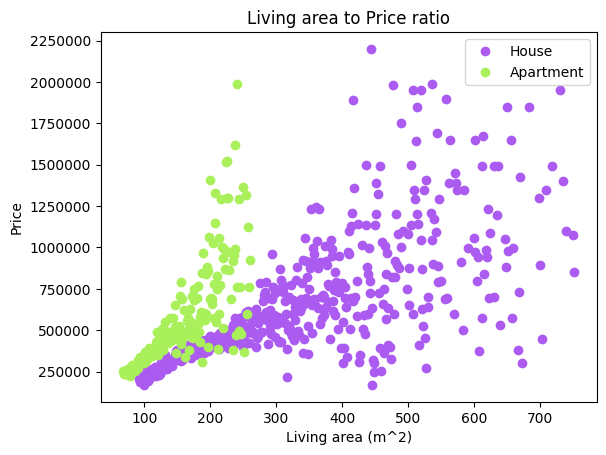

In [470]:
house_living_area = dataset[dataset.type == "house"].groupby("living_area")["price"].mean().to_frame().reset_index().iloc[50:-50]
apartment_living_area = dataset[dataset.type == "apartment"].groupby("living_area")["price"].mean().to_frame().reset_index().iloc[50:-50]
fig, ax = plt.subplots()
ax.plot(house_living_area.living_area, house_living_area.price, linestyle = "", marker = "o", color=colors["purple"])
ax.plot(apartment_living_area.living_area, apartment_living_area.price, linestyle = "", marker = "o", color=colors["green"])
ax.legend(["House", "Apartment"])
ax.set_xlabel("Living area (m^2)")
ax.set_ylabel("Price")
ax.ticklabel_format(style='plain', axis='y')
ax.set_title("Living area to Price ratio")
plt.show()

In [455]:
print("Correlation between Living area and Price for houses is: ",
      house_living_area.corr().iloc[0, 1] * 100 // 1 / 100, sep = "")
print("Correlation between Living area and Price for apartments is: ",
      apartment_living_area.corr().iloc[0, 1] * 100 // 1 / 100, sep = "")

Correlation between Living area and Price for houses is: 0.7
Correlation between Living area and Price for apartments is: 0.74


## Price based on Subtype

Checking if **STD** is lower than **MEAN**.

In [94]:
temp = dataset.groupby("subtype")["price"].agg(["std", "mean"])
temp.iloc[:,:] /= 1000
temp

,std,mean
subtype,,
apartment,213.127332,339.361342
bungalow,118.409251,342.454545
chalet,109.047979,232.887097
cottage,319.355606,547.416049
duplex,227.636907,380.773796
ground-floor,190.489423,333.665011
loft,292.508402,494.618395
mansion,436.643038,1237.500000
master-house,433.594169,688.747464


Results: **STD** gives lower values than **MEAN**. So we can use **MEAN** to create Bar Chart for Subtypes and Prices.

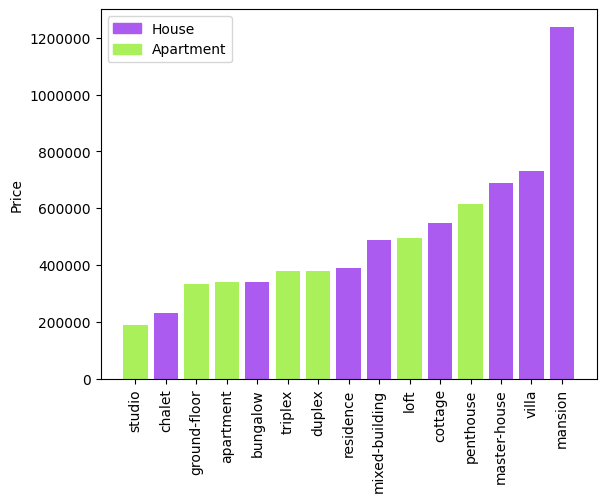

In [473]:
subtypes = dataset.groupby(["type", "subtype"])["price"].mean().to_frame().reset_index().sort_values("price")
subtypes["color"] = subtypes["type"].apply(lambda x: colors["purple"] if x == "house" else colors["green"])
legend = [
    Patch(color=colors["purple"], label = "House"),
    Patch(color=colors["green"], label = "Apartment")
]
fig, ax = plt.subplots()
ax.bar(subtypes.subtype, subtypes.price, color=subtypes.color)
ax.legend(handles = legend)
ax.set_ylabel("Price")
ax.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=90)
plt.show()